# Study 2: Platform as policy impliment

## Libraries

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from math import erf, sqrt
from scipy.stats import ttest_rel, wilcoxon, binomtest
from scipy.stats import binom
import folium

## Configuration

In [3]:
BUSINESS_JSON = "yelp_academic_dataset_business.json"
REVIEW_JSON   = "yelp_academic_dataset_review.json"

# Downtown Philadelphia (approx)
CENTER_LAT = 39.9526
CENTER_LON = -75.1652

# Outer study circle radius (km) — set large enough to cover Philadelphia
R_OUTER_KM = 60.0

MIN_USER_REVIEWS = 30

# Core circle radius (km)
R_CORE_KM = 15.0 #20


# Study period
START_DATE = pd.Timestamp("2010-01-01")
END_DATE   = pd.Timestamp("2020-01-01")  # exclusive end; includes all 2019

CHUNKSIZE = 100_000

# Utilities

In [4]:
# use to calcuate distances from centroid

def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized great-circle distance in km (supports scalars/arrays)."""
    lat1 = np.asarray(lat1, dtype=float)
    lon1 = np.asarray(lon1, dtype=float)
    lat2 = np.asarray(lat2, dtype=float)
    lon2 = np.asarray(lon2, dtype=float)

    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return 6371.0 * c

## 1. Load + Filter `businesses` to study circle

In [5]:
print("Loading businesses...")
biz = pd.read_json(BUSINESS_JSON, lines=True)[
    ["business_id", "name", "latitude", "longitude", "city", "state", "categories"]
].dropna(subset=["business_id", "latitude", "longitude"])

biz["dist_center_km"] = haversine_km(
    CENTER_LAT, CENTER_LON,
    biz["latitude"].values, biz["longitude"].values
)

biz_in = biz[biz["dist_center_km"] <= R_OUTER_KM].copy()
biz_in.reset_index(drop=True, inplace=True)

print(f"Businesses in circle (R={R_OUTER_KM} km): {len(biz_in)}")

# Build fast lookup: business_id -> (lat, lon)
biz_ids = set(biz_in["business_id"].tolist())
biz_coords = dict(zip(
    biz_in["business_id"].values,
    zip(biz_in["latitude"].values, biz_in["longitude"].values)
))

Loading businesses...
Businesses in circle (R=60.0 km): 44845


## 2. Chunk Lodd + Filter `reviews` to those businesses, and study period

In [6]:
print("\nFiltering reviews in chunks...")
#review_outpath = OUTDIR / "reviews_in_circle_2010_2019.parquet"

# We’ll build a list of chunk outputs, then concatenate once at the end.
# If you expect many millions of in-area reviews, we can instead write multiple part files.
kept_chunks = []
kept_rows = 0

usecols = ["review_id", "user_id", "business_id", "date", "stars", "text"]

for i, chunk in enumerate(pd.read_json(REVIEW_JSON, lines=True, chunksize=CHUNKSIZE)):
    print(f"  Chunk {i+1} (rows={len(chunk)})")

    chunk = chunk[usecols]

    # Filter to in-circle businesses
    chunk = chunk[chunk["business_id"].isin(biz_ids)]
    if chunk.empty:
        continue

    # Parse & filter dates (optional but usually what you want)
    chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")
    chunk = chunk.dropna(subset=["date"])

    chunk = chunk[(chunk["date"] >= START_DATE) & (chunk["date"] < END_DATE)]
    if chunk.empty:
        continue

    # Attach business lat/lon (use dict lookup; avoids merge overhead)
    lat = []
    lon = []
    for bid in chunk["business_id"].values:
        la, lo = biz_coords[bid]
        lat.append(la)
        lon.append(lo)
    chunk["latitude"] = np.array(lat, dtype=float)
    chunk["longitude"] = np.array(lon, dtype=float)

    kept_rows += len(chunk)
    kept_chunks.append(chunk)

print(f"\nTotal kept in-area+period reviews: {kept_rows}")


Filtering reviews in chunks...
  Chunk 1 (rows=100000)
  Chunk 2 (rows=100000)
  Chunk 3 (rows=100000)
  Chunk 4 (rows=100000)
  Chunk 5 (rows=100000)
  Chunk 6 (rows=100000)
  Chunk 7 (rows=100000)
  Chunk 8 (rows=100000)
  Chunk 9 (rows=100000)
  Chunk 10 (rows=100000)
  Chunk 11 (rows=100000)
  Chunk 12 (rows=100000)
  Chunk 13 (rows=100000)
  Chunk 14 (rows=100000)
  Chunk 15 (rows=100000)
  Chunk 16 (rows=100000)
  Chunk 17 (rows=100000)
  Chunk 18 (rows=100000)
  Chunk 19 (rows=100000)
  Chunk 20 (rows=100000)
  Chunk 21 (rows=100000)
  Chunk 22 (rows=100000)
  Chunk 23 (rows=100000)
  Chunk 24 (rows=100000)
  Chunk 25 (rows=100000)
  Chunk 26 (rows=100000)
  Chunk 27 (rows=100000)
  Chunk 28 (rows=100000)
  Chunk 29 (rows=100000)
  Chunk 30 (rows=100000)
  Chunk 31 (rows=100000)
  Chunk 32 (rows=100000)
  Chunk 33 (rows=100000)
  Chunk 34 (rows=100000)
  Chunk 35 (rows=100000)
  Chunk 36 (rows=100000)
  Chunk 37 (rows=100000)
  Chunk 38 (rows=100000)
  Chunk 39 (rows=100000)
  

In [7]:
reviews_in = pd.concat(kept_chunks, ignore_index=True)

## 3. Filter `users` according to number of reviews, and centroid location

In [8]:
# ----------------------------
# COUNT REVIEWS PER USER IN THIS SET
# ----------------------------
user_counts = (
    reviews_in.groupby("user_id")
    .size()
    .reset_index(name="n_reviews_in_set")
)

print(f"Unique users in set: {len(user_counts)}")

Unique users in set: 436063


In [9]:
# ----------------------------
# IDENTIFY ELIGIBLE USERS (MIN REVIEWS)
# ----------------------------
eligible_users = user_counts[user_counts["n_reviews_in_set"] >= MIN_USER_REVIEWS].copy()
eligible_user_ids = set(eligible_users["user_id"])

print(f"Eligible users (>= {MIN_USER_REVIEWS} reviews): {len(eligible_users)}")

Eligible users (>= 30 reviews): 5962


In [10]:
# ----------------------------
# FILTER REVIEWS TO ELIGIBLE USERS ACCORDING TO NUMBER OF REVIEWS
# ----------------------------
reviews_active = reviews_in[reviews_in["user_id"].isin(eligible_user_ids)].copy()

print(f"Reviews after user filter: {len(reviews_active)}")

Reviews after user filter: 442618


In [12]:
# ----------------------------
# COMPUTE USER CENTROIDS (MEAN LAT/LON)
# ----------------------------
centroids = (
    reviews_active.groupby("user_id")
    .agg(
        centroid_lat=("latitude", "mean"),
        centroid_lon=("longitude", "mean"),
        n_reviews=("review_id", "count") if "review_id" in reviews_active.columns else ("latitude", "count"),
    )
    .reset_index()
)

In [13]:
# ----------------------------
# CALCULATE USER REVIEW CENTROIDS
# ----------------------------
centroids["centroid_dist_km"] = haversine_km(
    CENTER_LAT, CENTER_LON,
    centroids["centroid_lat"].values,
    centroids["centroid_lon"].values
)

centroids["in_core"] = centroids["centroid_dist_km"] <= R_CORE_KM

core_centroids = centroids[centroids["in_core"]].copy()
core_user_ids = set(core_centroids["user_id"])

print(f"Users with centroid in core (R={R_CORE_KM} km): {len(core_centroids)}")

Users with centroid in core (R=15.0 km): 4231


In [14]:
# ----------------------------
# FILTER USERS AND REVIEWS TO CORE USERS (FILTER BY REVIEW CENTROIDS)
# ----------------------------
core_users = eligible_users[eligible_users["user_id"].isin(core_user_ids)].copy()
core_users = core_users.merge(
    core_centroids[["user_id", "centroid_lat", "centroid_lon", "centroid_dist_km"]],
    on="user_id",
    how="left"
)

core_user_reviews = reviews_active[reviews_active["user_id"].isin(core_user_ids)].copy()

print(f"Core users retained: {len(core_users)}")
print(f"Reviews retained: {len(core_user_reviews)}")

Core users retained: 4231
Reviews retained: 329985


In [15]:
# Businesses we actually care about
core_business_ids = set(core_user_reviews["business_id"].unique())
print(f"Businesses in core review set: {len(core_business_ids)}")

Businesses in core review set: 28617


## 4. Get users' `first-reviews` from entire review dataset

In [16]:
# ------------------------------------------------------------
# PASS OVER FULL DATASET: FIND FIRST-EVER REVIEW PER BUSINESS
# ------------------------------------------------------------
print("\nScanning full Yelp review dataset for first-ever reviews...")

first_date = defaultdict(lambda: pd.Timestamp.max)
first_user = {}

for i, chunk in enumerate(pd.read_json(REVIEW_JSON, lines=True, chunksize=CHUNKSIZE)):
    print(f"  Chunk {i+1}")

    chunk = chunk[["business_id", "user_id", "date"]]
    chunk = chunk[chunk["business_id"].isin(core_business_ids)]
    if chunk.empty:
        continue

    chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")
    chunk = chunk.dropna(subset=["date"])
    if chunk.empty:
        continue

    for bid, uid, d in zip(chunk["business_id"], chunk["user_id"], chunk["date"]):
        if d < first_date[bid]:
            first_date[bid] = d
            first_user[bid] = uid

print(f"Businesses with identified first-ever reviews: {len(first_user)}")


Scanning full Yelp review dataset for first-ever reviews...
  Chunk 1
  Chunk 2
  Chunk 3
  Chunk 4
  Chunk 5
  Chunk 6
  Chunk 7
  Chunk 8
  Chunk 9
  Chunk 10
  Chunk 11
  Chunk 12
  Chunk 13
  Chunk 14
  Chunk 15
  Chunk 16
  Chunk 17
  Chunk 18
  Chunk 19
  Chunk 20
  Chunk 21
  Chunk 22
  Chunk 23
  Chunk 24
  Chunk 25
  Chunk 26
  Chunk 27
  Chunk 28
  Chunk 29
  Chunk 30
  Chunk 31
  Chunk 32
  Chunk 33
  Chunk 34
  Chunk 35
  Chunk 36
  Chunk 37
  Chunk 38
  Chunk 39
  Chunk 40
  Chunk 41
  Chunk 42
  Chunk 43
  Chunk 44
  Chunk 45
  Chunk 46
  Chunk 47
  Chunk 48
  Chunk 49
  Chunk 50
  Chunk 51
  Chunk 52
  Chunk 53
  Chunk 54
  Chunk 55
  Chunk 56
  Chunk 57
  Chunk 58
  Chunk 59
  Chunk 60
  Chunk 61
  Chunk 62
  Chunk 63
  Chunk 64
  Chunk 65
  Chunk 66
  Chunk 67
  Chunk 68
  Chunk 69
  Chunk 70
Businesses with identified first-ever reviews: 28617


In [17]:
# ------------------------------------------------------------
# FLAG FIRST-EVER REVIEWS IN CORE REVIEW SET
# ------------------------------------------------------------
def is_first_ever(row):
    bid = row["business_id"]
    return (
        first_user.get(bid) == row["user_id"]
        and first_date.get(bid) == row["date"]
    )

core_user_reviews["is_first_review"] = core_user_reviews.apply(is_first_ever, axis=1)

print("First-ever reviews found in core set:",
      core_user_reviews["is_first_review"].sum())

First-ever reviews found in core set: 7408


In [18]:
# ------------------------------------------------------------
# AGGREGATE TO USER LEVEL
# ------------------------------------------------------------
user_stats = (
    core_user_reviews
    .groupby("user_id")
    .agg(
        total_reviews=("business_id", "count"),
        first_reviews=("is_first_review", "sum")
    )
    .reset_index()
)

user_stats["first_review_share"] = (
    user_stats["first_reviews"] / user_stats["total_reviews"]
)

print(user_stats.describe())

       total_reviews  first_reviews  first_review_share
count    4231.000000    4231.000000         4231.000000
mean       77.992200       1.750886            0.019546
std        83.173195       4.564780            0.031999
min        30.000000       0.000000            0.000000
25%        37.000000       0.000000            0.000000
50%        51.000000       1.000000            0.005988
75%        85.000000       2.000000            0.028571
max      2144.000000     120.000000            0.487179


## 5. Compute binomially expected first-reivew rates and identify scouts

In [19]:
# ------------------------------------------------------------
# GLOBAL EXPECTED FIRST-REVIEW RATE p
# ------------------------------------------------------------
total_first = user_stats["first_reviews"].sum()
total_reviews = user_stats["total_reviews"].sum()

p_hat = total_first / total_reviews

print("\n=== Expected first-review rate ===")
print(f"Total first reviews: {total_first}")
print(f"Total reviews:       {total_reviews}")
print(f"p (expected rate):   {p_hat:.6f}")


=== Expected first-review rate ===
Total first reviews: 7408
Total reviews:       329985
p (expected rate):   0.022450


In [20]:
# ------------------------------------------------------------
# BINOMIAL STANDARDIZED RESIDUAL (z-score)
# ------------------------------------------------------------
# Variance under binomial: N p (1-p)
var = user_stats["total_reviews"] * p_hat * (1 - p_hat)

# Avoid division by zero (should not happen if p_hat>0 and N>0)
user_stats["z_first_review"] = (user_stats["first_reviews"] - user_stats["total_reviews"] * p_hat) / np.sqrt(var)

In [21]:
# Grid of candidate thresholds
Z_MIN = 0.0
Z_MAX = 5.05
Z_STEP = 0.05

In [22]:
# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_sf(z):
    """
    Survival function 1 - Phi(z) for standard normal.
    Uses erf (no scipy needed).
    """
    # Phi(z) = 0.5 * (1 + erf(z / sqrt(2)))
    phi = 0.5 * (1.0 + erf(z / sqrt(2.0)))
    return 1.0 - phi


def expected_exact(t, ns, p_hat):
    total = 0
    for n in ns:
        mu = n * p_hat
        sigma = np.sqrt(n * p_hat * (1 - p_hat))
        k_star = int(np.ceil(mu + t * sigma))
        if k_star <= 0:
            total += 1.0
        elif k_star > n:
            total += 0.0
        else:
            total += binom.sf(k_star - 1, n, p_hat)  # P(K >= k_star)
    return total



In [ ]:
# ------------------------------------------------------------
# EXTRACT RESIDUALS
# ------------------------------------------------------------

z = user_stats["z_first_review"].replace([np.inf, -np.inf], np.nan).dropna().values
n = len(z)

print(f"Loaded users with valid z: {n}")
if n == 0:
    raise RuntimeError("No valid z scores found.")

Loaded users with valid z: 4231


In [30]:
# ------------------------------------------------------------
# COMPUTE OBSERVED VS EXPECTED TAIL COUNTS
# ------------------------------------------------------------
thresholds = np.arange(Z_MIN, Z_MAX + 1e-9, Z_STEP)

observed = np.array([(z >= t).sum() for t in thresholds], dtype=float)
#expected = np.array([n * norm_sf(t) for t in thresholds], dtype=float)
ns = user_stats['total_reviews'].values  # array of n_i
expected_0 = [expected_exact(t, ns, p_hat) for t in thresholds]
expected_0 = np.array(expected_0, dtype=float)

excess = observed - expected_0
ratio = np.divide(observed, expected_0, out=np.full_like(observed, np.nan), where=(expected_0 > 0))

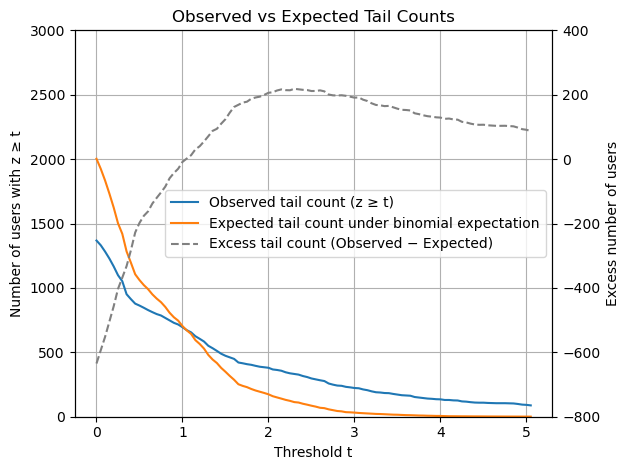

In [ ]:
# ------------------------------------------------------------
# PLOT 1: OBSERVED VS EXPECTED TAIL COUNTS
# ------------------------------------------------------------
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.set_ylim(0,3000)
ax2.set_ylim(-800,400)

lns1 = ax1.plot(thresholds, observed, label="Observed tail count (z ≥ t)")
lns2 = ax1.plot(thresholds, expected_0, label="Expected tail count under binomial expectation")
lns3 = ax2.plot(thresholds, excess, linestyle='dashed', color='grey', label="Excess tail count (Observed − Expected)")

ax1.set_xlabel("Threshold t")
ax1.set_ylabel("Number of users with z ≥ t")
ax2.set_ylabel("Excess number of users")

# added these three lines
lns = lns1+lns2+lns3
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=5)

plt.title("Observed vs Expected Tail Counts")
ax1.grid(True)

plt.tight_layout()

#plt.savefig('study2plot1.png', dpi=300)

In [33]:
# Scout threshold
Z_SCOUT = 2.5 # increase if you want to be more conservative

In [34]:
# ------------------------------------------------------------
# IDENTIFY SCOUTS
# ------------------------------------------------------------
user_stats["is_scout"] = user_stats["z_first_review"] > Z_SCOUT

print("\n=== Scout identification ===")
print(f"Z threshold: {Z_SCOUT}")
print(f"Number of scouts: {user_stats['is_scout'].sum()}")
print(f"Share of users who are scouts: {user_stats['is_scout'].mean():.4f}")

# Summary of scouts vs non-scouts
summary = (
    user_stats.assign(group=lambda x: np.where(x["is_scout"], "Scout", "Non-scout"))
      .groupby("group")
      .agg(
          n_users=("user_id", "count"),
          mean_reviews=("total_reviews", "mean"),
          mean_first_reviews=("first_reviews", "mean"),
          mean_first_share=("first_review_share", "mean"),
          mean_z=("z_first_review", "mean")
      )
)

print("\n=== Group summary ===")
print(summary)


=== Scout identification ===
Z threshold: 2.5
Number of scouts: 297
Share of users who are scouts: 0.0702

=== Group summary ===
           n_users  mean_reviews  mean_first_reviews  mean_first_share  \
group                                                                    
Non-scout     3934     73.928826            1.053127          0.013216   
Scout          297    131.814815           10.993266          0.103388   

             mean_z  
group                
Non-scout -0.480975  
Scout      4.905123  


## 6. Match each scout with non-scout 

In [35]:
# ------------------------------------------------------------
# SPLIT SCOUTS AND CONTROLS
# ------------------------------------------------------------
scouts = user_stats[user_stats["is_scout"]].copy()

controls_pool = user_stats[
    (~user_stats["is_scout"]) &
    (user_stats["first_reviews"] == 0)
].copy()

print(f"Scout candidates: {len(scouts)}")
print(f"Control pool (zero first-reviews): {len(controls_pool)}")

if scouts.empty:
    raise RuntimeError("No scouts found. Check your threshold definition.")

if controls_pool.empty:
    raise RuntimeError("No eligible controls with zero first-reviews.")

Scout candidates: 297
Control pool (zero first-reviews): 2087


In [36]:
# ------------------------------------------------------------
# PREPARE CONTROL AVAILABILITY
# ------------------------------------------------------------
controls_pool = controls_pool.sort_values("total_reviews")
controls_pool["available"] = True

# Shuffle scouts so matching order does not bias results
scouts = scouts.sample(frac=1.0, random_state=42).reset_index(drop=True)

In [37]:
# ------------------------------------------------------------
# ONE-TO-ONE MATCHING (NO REPLACEMENT)
# ------------------------------------------------------------
matches = []

for _, s in scouts.iterrows():
    n = int(s["total_reviews"])

    # eligible controls with same total reviews and not yet used
    cand = controls_pool[
        (controls_pool["available"]) &
        (controls_pool["total_reviews"] == n)
    ]

    if cand.empty:
        continue  # scout remains unmatched

    # take the first available control
    c_idx = cand.index[0]
    c = controls_pool.loc[c_idx]

    # mark control as used
    controls_pool.loc[c_idx, "available"] = False

    matches.append({
        "scout_user_id": s["user_id"],
        "control_user_id": c["user_id"],
        "total_reviews": n,
        "scout_first_reviews": int(s["first_reviews"]),
        "control_first_reviews": int(c["first_reviews"]),
        "scout_z": float(s["z_first_review"]),
        "control_z": float(c["z_first_review"]),
    })

matches_df = pd.DataFrame(matches)

print("\n=== Matching results ===")
print(f"Matched pairs: {len(matches_df)}")
print(f"Unmatched scouts: {len(scouts) - len(matches_df)}")


=== Matching results ===
Matched pairs: 227
Unmatched scouts: 70


## 7. Calculate user mobility metrics

In [39]:
def compute_user_metrics(df_user):
    """
    df_user: reviews for ONE user, must include date, latitude, longitude.
    Returns (r_g_km, path_length_km, n_points).
    """
    if df_user.empty:
        return np.nan, np.nan, 0

    # Sort for path length
    df_user = df_user.sort_values("date")

    lats = df_user["latitude"].to_numpy(dtype=float)
    lons = df_user["longitude"].to_numpy(dtype=float)

    n = len(lats)
    if n == 0:
        return np.nan, np.nan, 0

    # centroid
    c_lat = float(lats.mean())
    c_lon = float(lons.mean())

    # radius of gyration: sqrt(mean squared distance to centroid)
    d = haversine_km(c_lat, c_lon, lats, lons)
    r_g = float(np.sqrt(np.mean(d**2)))

    # total path length: sum consecutive step distances
    if n >= 2:
        step = haversine_km(lats[:-1], lons[:-1], lats[1:], lons[1:])
        path_len = float(step.sum())
    else:
        path_len = 0.0

    return r_g, path_len, n


def paired_report(pairs, scout_col, control_col, label):
    s = pairs[scout_col].astype(float)
    c = pairs[control_col].astype(float)
    diff = s - c

    print(f"\n=== {label} ===")
    print(f"Pairs: {len(pairs)}")
    print(f"Scout mean:   {s.mean():.3f}")
    print(f"Control mean: {c.mean():.3f}")
    print(f"Mean diff:    {diff.mean():.3f}")
    print(f"Median diff:  {diff.median():.3f}")

    # Paired tests
    t_p = ttest_rel(s, c).pvalue
    w_p = wilcoxon(s, c).pvalue
    print(f"Paired t-test p: {t_p:.6f}")
    print(f"Wilcoxon p:      {w_p:.6f}")

    # Directional dominance
    wins = int((s > c).sum())
    total = len(pairs)
    bt = binomtest(wins, total, p=0.5, alternative="greater")
    print(f"Scout > control: {wins}/{total} = {wins/total:.3f}")
    print(f"Binomial p:      {bt.pvalue:.6f}")

In [40]:
# ------------------------------------------------------------
# COMPUTE MOBILITY METRICS PER USER
# ------------------------------------------------------------
metrics_rows = []

for uid, dfu in core_user_reviews.groupby("user_id"):
    r_g, path_len, n_points = compute_user_metrics(dfu)
    metrics_rows.append({
        "user_id": uid,
        "n_points": n_points,
        "r_g_km": r_g,
        "path_length_km": path_len
    })

metrics_df = pd.DataFrame(metrics_rows)

In [41]:
# ------------------------------------------------------------
# MERGE INTO MATCHED PAIRS
# ------------------------------------------------------------
pairs = matches_df.merge(
    metrics_df.add_prefix("scout_"),
    left_on="scout_user_id",
    right_on="scout_user_id",
    how="left"
).merge(
    metrics_df.add_prefix("control_"),
    left_on="control_user_id",
    right_on="control_user_id",
    how="left"
)

pairs = pairs.dropna(subset=[
    "scout_r_g_km", "control_r_g_km",
    "scout_path_length_km", "control_path_length_km"
]).copy()

print(f"Pairs with complete mobility metrics: {len(pairs)}")

if pairs.empty:
    raise RuntimeError("After merging, no pairs have complete mobility metrics.")

Pairs with complete mobility metrics: 227


In [42]:
# ------------------------------------------------------------
# RUN PAIRED STATISTICAL TESTS
# ------------------------------------------------------------
paired_report(pairs, "scout_r_g_km", "control_r_g_km", "Radius of gyration (km)")
paired_report(pairs, "scout_path_length_km", "control_path_length_km", "Total path length (km)")


=== Radius of gyration (km) ===
Pairs: 227
Scout mean:   10.914
Control mean: 8.448
Mean diff:    2.465
Median diff:  2.551
Paired t-test p: 0.000000
Wilcoxon p:      0.000000
Scout > control: 148/227 = 0.652
Binomial p:      0.000003

=== Total path length (km) ===
Pairs: 227
Scout mean:   679.134
Control mean: 514.864
Mean diff:    164.270
Median diff:  131.465
Paired t-test p: 0.000002
Wilcoxon p:      0.000000
Scout > control: 154/227 = 0.678
Binomial p:      0.000000
